# Modelagem de Churn — Telco Customer Churn

---

**Objetivo:** Treinar, otimizar e validar modelos de classificação binária para prever a probabilidade de churn (cancelamento) de clientes de telecomunicações, selecionando a estratégia de threshold que minimizasse a perda líquida de receita.

**Contexto do problema:**
O churn de clientes é um dos principais desafios em telecomunicações. Identificar com antecedência quais clientes tinham maior risco de cancelar permitiria direcionar campanhas de retenção de forma proativa e reduzir perdas de receita. Este notebook implementou uma abordagem estruturada e incremental de modelagem, partindo de um modelo simples até técnicas avançadas de otimização.

> **Nota sobre cenário simulado:** O dataset utilizado ([IBM Telco Customer Churn](https://www.kaggle.com/blastchar/telco-customer-churn)) contém apenas dados de perfil e uso de clientes. **Não contém informações reais sobre campanhas de retenção, custos operacionais ou taxas de sucesso de retenção.** A análise de impacto financeiro (Business Impact) realizada neste notebook utilizou **premissas simuladas**, baseadas em benchmarks da indústria de telecomunicações, para demonstrar como o modelo teria sido avaliado em um cenário real de produção. Os valores específicos (custo de campanha, taxa de retenção) deveriam ser substituídos por dados reais da empresa antes de qualquer decisão de negócio.

**Decisões Técnicas:**

| Aspecto | Decisão | Justificativa |
|---------|---------|---------------|
| Métrica de otimização | AUPRC (`average_precision_score`) | Threshold-independente, foca na classe positiva, estável para Optuna |
| Seleção de threshold | Análise financeira (4 estratégias) | Precision vs Recall vs F1 vs Ótimo de Negócio — escolheu pela menor perda de receita |
| CV Strategy | Stratified K-Fold (5 folds) | Manteve a proporção de churn em cada fold, reduziu variância da estimativa |
| Otimização | Optuna (TPE Bayesiano) | Convergiu mais rápido que Grid/Random Search, priorizou regiões promissoras do espaço |
| Modelos | XGBoost, LightGBM, CatBoost | Os 3 principais frameworks de gradient boosting — competição entre eles selecionou o melhor |
| Balanceamento | `scale_pos_weight` / `class_weight` | Otimizado como hiperparâmetro por Optuna (1.5x–12x), mais estável que SMOTE |

---

## 1. Setup e Configurações

Importação de bibliotecas, configuração de paths e definição de constantes do experimento. As dependências incluíram:

- **Scikit-learn** — pipeline de pré-processamento, modelos base e métricas de avaliação
- **XGBoost / LightGBM** — algoritmos de gradient boosting de alta performance
- **Optuna** — framework de otimização Bayesiana de hiperparâmetros (sampler TPE)
- **MLflow** — rastreamento de experimentos para reprodutibilidade e comparação de runs
- **imbalanced-learn** *(opcional)* — técnicas de reamostragem (SMOTETomek) para lidar com desbalanceamento de classes
- **Módulos do projeto** (`src/`) — feature engineering, preprocessing e avaliação reutilizáveis

In [1]:
import sys
import warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    average_precision_score,
    confusion_matrix, precision_recall_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

# Boosting
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Optuna
import optuna
from optuna.samplers import TPESampler

# MLflow
import mlflow
import mlflow.sklearn

# imbalanced-learn (para SMOTE — disponibilidade futura)
try:
    from imblearn.combine import SMOTETomek
    IMBLEARN_AVAILABLE = True
except ImportError:
    IMBLEARN_AVAILABLE = False
    print("[WARN] imblearn nao instalado - SMOTE desabilitado")

# Path do projeto
PROJ_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJ_ROOT))

# Modulos do projeto
from src.config import (
    DATA_DIR_RAW, FILENAME, TARGET, ID_COL,
    TEST_SIZE, RANDOM_STATE,
    NUMERIC_FEATURES, CATEGORICAL_FEATURES
)
from src.feature_engineering import FeatureEngineer, AdvancedFeatureEngineer
from src.preprocessing import build_preprocessor

warnings.filterwarnings('ignore')
np.random.seed(RANDOM_STATE)

print(f"Setup concluido | Projeto: {PROJ_ROOT.name}")
if IMBLEARN_AVAILABLE:
    print("imblearn disponivel - SMOTE habilitado")

Setup concluido | Projeto: telco_churn_clients
imblearn disponivel - SMOTE habilitado


In [2]:
# Configuracoes do experimento
MLFLOW_DIR = PROJ_ROOT / "mlruns"
MODELS_DIR = PROJ_ROOT / "models"
OPTUNA_DIR = PROJ_ROOT / "optuna_studies"

for d in [MLFLOW_DIR, MODELS_DIR, OPTUNA_DIR]:
 d.mkdir(exist_ok=True)

# MLflow
mlflow.set_tracking_uri(MLFLOW_DIR.as_uri())
EXPERIMENT_NAME = "churn_modeling_v2"
mlflow.set_experiment(EXPERIMENT_NAME)

# Optuna config
N_TRIALS_OPT = 100
CV_FOLDS_OPT = 5
NUM_PATIENCE = 50

print(f"MLflow: {EXPERIMENT_NAME}")
print(f"Optuna: {N_TRIALS_OPT} trials, {CV_FOLDS_OPT}-fold CV")
print(f"Early stopping patience: {NUM_PATIENCE} trials")

MLflow: churn_modeling_v2
Optuna: 100 trials, 5-fold CV
Early stopping patience: 50 trials


## 2. Carregamento e Preparação dos Dados

Nesta etapa, carregamos o dataset original (sem transformações prévias) e realizamos a separação entre **features** (`X`) e **target** (`y`).

- A coluna target (`Churn`) foi codificada em formato binário (`0 = No Churn`, `1 = Churn`) para compatibilidade com os algoritmos de classificação.
- A coluna de identificação (`customerID`) foi removida das features, pois não carregava informação preditiva.
- A distribuição de classes foi verificada para confirmar o **desbalanceamento** esperado (tipicamente ~26% de churn neste dataset).

In [3]:
# Carregar dados RAW
df = pd.read_csv(DATA_DIR_RAW / FILENAME)
print(f"Dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas")

# Separar features e target
X = df.drop(columns=[TARGET, ID_COL])
y = df[TARGET]

# Converter target para binário
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes: {label_encoder.classes_} → [0, 1]")
print(f"Distribuição: {np.bincount(y_encoded)} (No Churn / Churn)")

Dataset: 7,043 linhas × 21 colunas
Classes: ['No' 'Yes'] → [0, 1]
Distribuição: [5174 1869] (No Churn / Churn)


### Divisão Treino/Teste — Split Estratificado

Por se tratar de uma base de dados **desbalanceada** (~26% de churn vs ~74% de não-churn), utilizamos `train_test_split` com o parâmetro `stratify=y_encoded`. Isso garantiu que os subconjuntos de treinamento e teste resultantes **mantivessem a mesma proporção de rótulos de classe** que o dataset original.

**Por que isso foi importante?**
- Sem estratificação, uma divisão aleatória poderia ter concentrado mais churners em um dos conjuntos, distorcendo tanto o treinamento quanto a avaliação.
- A estratificação assegurou que métricas calculadas no test set fossem representativas do cenário real de produção.
- A proporção `test_size` foi definida em `config.py` para manter consistência entre notebooks e scripts.

In [4]:
# Split train/test estratificado
X_train, X_test, y_train, y_test = train_test_split(
 X, y_encoded,
 test_size=TEST_SIZE,
 stratify=y_encoded,
 random_state=RANDOM_STATE
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Churn rate (train): {y_train.mean():.1%}")
print(f"Churn rate (test): {y_test.mean():.1%}")

Train: 5,634 | Test: 1,409
Churn rate (train): 26.5%
Churn rate (test): 26.5%


## 3. Feature Engineering Pipeline

Utilizamos `FeatureEngineer` (`src/feature_engineering.py`) para criar variáveis que aumentaram o sinal preditivo de churn sem gerar leakage.

### Features derivadas e justificativa

| Feature | Como foi criada | Por que ajudou no churn |
|---|---|---|
| `tenure_group` | Faixas de tempo de casa (ex.: 0–12, 13–24, 25–48, 49+) | Churn era mais alto em clientes mais novos |
| `avg_monthly_charge` | `TotalCharges / tenure` (com proteção para `tenure=0`) | Capturou custo médio real e variações de cobrança |
| `is_new_customer` | Indicador para baixo tenure (ex.: `tenure <= 3`) | Novos clientes tinham maior risco de cancelamento |
| `num_services` | Contagem de serviços ativos (internet, segurança, backup, streaming etc.) | Maior adoção tendia a reduzir churn (maior lock-in) |
| `has_fiber` | `InternetService == 'Fiber optic'` | Clientes de Fibra Ótica tinham perfil de preço/satisfação diferente |
| `is_month_to_month` | `Contract == 'Month-to-month'` | Contratos mensais tinham menor compromisso e maior churn |
| `is_electronic_check` | `PaymentMethod == 'Electronic check'` | Método de pagamento refletia maior propensão ao churn |
| `has_security_support` | Combinação de `OnlineSecurity` e `TechSupport` | Ausência desses serviços geralmente aumentava risco de saída |
| `charges_per_service` | `MonthlyCharges / (num_services + 1)` | Mediu percepção de custo por serviço contratado |
| `total_charges_missing_flag` | Flag para `TotalCharges` ausente/zero antes de imputação | Ausência indicava cliente muito recente |

### Tratamento de `TotalCharges`

- Conversão para numérico com coerção de erros.
- Preenchimento de ausências (principalmente novos clientes com `tenure=0`) dentro do pipeline.
- Criação de flag de ausência para preservar informação útil.

### Controle de data leakage

- `fit` do pipeline **apenas em `X_train`**.
- `transform` em `X_test` usando estatísticas aprendidas no treino.
- Toda imputação/escala/encoding ocorreu dentro do pipeline para garantir reprodutibilidade.

In [5]:
# Construir pipeline completo (Feature Engineering + Preprocessing)
feature_engineer = FeatureEngineer()
preprocessor = build_preprocessor(
    numeric_features=NUMERIC_FEATURES,
    categorical_features=CATEGORICAL_FEATURES,
    scaler_type='standard'
)

pipeline_base = Pipeline([
    ('feature_engineering', feature_engineer),
    ('preprocessing', preprocessor),
])

# Fit no treino, transform em ambos
X_train_processed = pipeline_base.fit_transform(X_train, y_train)
X_test_processed = pipeline_base.transform(X_test)

print(f"Pipeline ajustado")
print(f"  Features originais: {X_train.shape[1]}")
print(f"  Features processadas: {X_train_processed.shape[1]}")

2026-03-05 16:22:53 - src.preprocessing - INFO - Construindo preprocessador
2026-03-05 16:22:53 - src.preprocessing - INFO - Scaler selecionado: standard
2026-03-05 16:22:53 - src.preprocessing - INFO - Pipeline numérico configurado: 3 features
2026-03-05 16:22:53 - src.preprocessing - INFO - Pipeline categórico configurado: 16 features
2026-03-05 16:22:53 - src.preprocessing - INFO - Preprocessador construído com sucesso
2026-03-05 16:22:53 - src.feature_engineering - INFO - Iniciando fit do FeatureEngineer
2026-03-05 16:22:53 - src.feature_engineering - INFO - Shape de entrada: (5634, 19)
2026-03-05 16:22:53 - src.feature_engineering - INFO - Bins de MonthlyCharges: [ 18.4     35.6625  70.5     90.     118.75  ]
2026-03-05 16:22:53 - src.feature_engineering - INFO - Mediana avg_monthly_charge: 70.58
2026-03-05 16:22:53 - src.feature_engineering - INFO - Mediana MonthlyCharges: 70.50
2026-03-05 16:22:53 - src.feature_engineering - INFO - Tenure médio por contrato: {'Month-to-month': 1

Pipeline ajustado
  Features originais: 19
  Features processadas: 46


## 4. FASE 1: Baseline — Regressão Logística

O primeiro passo da pipeline de modelagem foi estabelecer um **modelo baseline**. Ele serviu como referência mínima de desempenho: qualquer modelo mais complexo deveria superar o baseline para justificar sua adoção.

**Por que Logistic Regression?**
- É um modelo **interpretável e rápido**, ideal como ponto de partida.
- O parâmetro `class_weight='balanced'` ajustou automaticamente os pesos das classes de forma inversamente proporcional à sua frequência, compensando o desbalanceamento sem necessidade de reamostragem.
- Permitiu avaliar se o problema possuía **sinal linear** nas features — se o baseline já performasse bem, modelos mais complexos poderiam ter ganhos marginais.

In [6]:
# Modelo baseline
baseline = LogisticRegression(
 max_iter=1000,
 class_weight='balanced',
 random_state=RANDOM_STATE
)

baseline.fit(X_train_processed, y_train)

# Avaliacao
y_pred_base = baseline.predict(X_test_processed)
y_proba_base = baseline.predict_proba(X_test_processed)[:, 1]

baseline_metrics = {
 'F1-Score': f1_score(y_test, y_pred_base),
 'ROC-AUC': roc_auc_score(y_test, y_proba_base),
 'Precision': precision_score(y_test, y_pred_base),
 'Recall': recall_score(y_test, y_pred_base)
}

print("BASELINE - Logistic Regression")
print("="*40)
for metric, value in baseline_metrics.items():
 print(f" {metric}: {value:.4f}")

BASELINE - Logistic Regression
 F1-Score: 0.6136
 ROC-AUC: 0.8415
 Precision: 0.5043
 Recall: 0.7834


## 5. Otimização e Seleção de Modelos

Seção unificada que combinou **feature engineering avançado**, **otimização de hiperparâmetros** via Optuna (TPE Bayesiano) e **seleção automática** do melhor modelo.

### Pipeline de Otimização

| Etapa | Descrição | Por que foi usada |
|-------|-----------|-------------------|
| Feature Engineering | `AdvancedFeatureEngineer` + remoção de features com IV=0 | Criou interações e indicadores que capturaram padrões não-lineares de churn; IV=0 indicou zero contribuição preditiva |
| Preprocessing | `StandardScaler` + `OneHotEncoder` via `ColumnTransformer` | Normalizou features numéricas (necessário para regularização L2) e codificou categóricas como dummies |
| Modelos | XGBoost, LightGBM, CatBoost | Os 3 frameworks de gradient boosting mais eficientes — competiram entre si e o Optuna selecionou automaticamente o melhor |
| Balanceamento | `scale_pos_weight` / `class_weight` otimizado via Optuna (1.5x–12x) | Penalizou erros na classe minoritária (churn) proporcionalmente ao peso, mais estável que reamostragem (SMOTE) |
| CV | 5-fold Stratified com `cross_val_predict` | Gerou predições out-of-fold para cada amostra sem vazamento de dados |
| Trials | Até `N_TRIALS_OPT` com early stopping opcional | Early stopping evitou desperdício computacional após convergência |

### Métrica de Otimização: AUPRC (Average Precision)

**AUPRC** (`average_precision_score`) foi escolhida como objetivo por ser:

1. **Threshold-independente**: Mediu a qualidade do *ranking* de probabilidades em **todos** os thresholds possíveis, sem forçar uma decisão binária durante a otimização.
2. **Focada na classe positiva**: Diferente do ROC-AUC, que considera True Negatives (inflando a métrica em dados desbalanceados), a AUPRC avaliou apenas a relação Precision-Recall sobre os positivos (churners).
3. **Estável entre trials**: Otimizar F1 no "threshold ótimo por trial" era ruidoso — cada trial encontrava um threshold diferente, gerando alta variância na métrica. AUPRC não teve esse problema.

$$\text{AUPRC} = \sum_{k=1}^{n} (R_k - R_{k-1}) \cdot P_k$$

onde $P_k$ e $R_k$ são a Precision e Recall no k-ésimo threshold.

### Separação: Otimização vs Decisão de Threshold

A decisão de threshold foi **separada** da otimização:

- **Otimização (Optuna):** Encontrou os melhores hiperparâmetros usando AUPRC (sem threshold fixo).
- **Threshold (pós-otimização):** Após selecionar o modelo, avaliamos 4 estratégias de threshold com base no impacto financeiro.

Essa separação garantiu que a **seleção do modelo** não fosse contaminada por uma escolha de threshold que podia variar conforme as necessidades de negócio.

In [7]:
# ============================================================
# FEATURE ENGINEERING AVANCADO + PREPROCESSING
# ============================================================
from catboost import CatBoostClassifier
from sklearn.base import clone

USE_EARLY_STOPPING = True   # True = para apos NUM_PATIENCE trials sem melhora; False = roda todos os N_TRIALS_OPT

# 1. AdvancedFeatureEngineer
print("FEATURE ENGINEERING AVANCADO")
print("="*60)

X_train_reset = X_train.reset_index(drop=True)
X_test_reset = X_test.reset_index(drop=True)
y_train_reset = pd.Series(y_train).reset_index(drop=True)

advanced_fe = AdvancedFeatureEngineer(convert_target=False)
X_train_adv = advanced_fe.fit_transform(X_train_reset, y_train_reset)
X_test_adv = advanced_fe.transform(X_test_reset)

print(f"Features originais: {X_train.shape[1]}")
print(f"Features apos AdvancedFE: {X_train_adv.shape[1]}")

# 2. Remover features com IV=0 (zero poder preditivo)
iv_zero_features = [
    'new_customer_flag', 'charges_mismatch_flag', 'is_high_MonthlyCharges',
    'is_monthly_contract', 'long_term_contract', 'early_churn_risk',
    'price_sensitive_contract', 'SeniorCitizen'
]
cols_to_drop = [c for c in iv_zero_features if c in X_train_adv.columns]
if cols_to_drop:
    X_train_adv = X_train_adv.drop(columns=cols_to_drop)
    X_test_adv = X_test_adv.drop(columns=cols_to_drop)
    print(f"Removidas {len(cols_to_drop)} features com IV=0")
print(f"Features finais: {X_train_adv.shape[1]}")

# 3. Preprocessing (StandardScaler + OneHotEncoder)
numeric_cols = X_train_adv.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X_train_adv.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor_adv = build_preprocessor(
    numeric_features=numeric_cols,
    categorical_features=categorical_cols
)

preprocessor_fitted = clone(preprocessor_adv)
X_train_opt = preprocessor_fitted.fit_transform(X_train_adv)
X_test_opt = preprocessor_fitted.transform(X_test_adv)

print(f"Apos preprocessing: {X_train_opt.shape[1]} features")
print(f"Train: {X_train_opt.shape[0]} | Test: {X_test_opt.shape[0]}")

# Ratio de desbalanceamento
neg, pos = np.bincount(y_train.astype(int))
ratio = neg / pos
print(f"\nDesbalanceamento: {neg} neg / {pos} pos (ratio={ratio:.2f})")
print(f"class_weight='balanced' equivale a ~{{0: 1, 1: {ratio:.1f}}}")
print(f"\nEarly stopping: {'ATIVADO (patience=' + str(NUM_PATIENCE) + ')' if USE_EARLY_STOPPING else 'DESATIVADO (roda todos os ' + str(N_TRIALS_OPT) + ' trials)'}")

2026-03-05 16:22:57 - src.feature_engineering - INFO - Iniciando fit do FeatureEngineer
2026-03-05 16:22:57 - src.feature_engineering - INFO - Shape de entrada: (5634, 19)
2026-03-05 16:22:57 - src.feature_engineering - INFO - Bins de MonthlyCharges: [ 18.4     35.6625  70.5     90.     118.75  ]
2026-03-05 16:22:57 - src.feature_engineering - INFO - Mediana avg_monthly_charge: 70.58
2026-03-05 16:22:57 - src.feature_engineering - INFO - Mediana MonthlyCharges: 70.50
2026-03-05 16:22:57 - src.feature_engineering - INFO - Tenure médio por contrato: {'Month-to-month': 18.131205673758867, 'One year': 42.44330775788576, 'Two year': 56.65342163355408}
2026-03-05 16:22:57 - src.feature_engineering - INFO - Mapeamento ordinal: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
2026-03-05 16:22:57 - src.feature_engineering - INFO - Taxa de churn por contrato: {'Month-to-month': 0.4274661508704062, 'One year': 0.11082693947144075, 'Two year': 0.02869757174392936}
2026-03-05 16:22:57 - src.feat

FEATURE ENGINEERING AVANCADO


2026-03-05 16:22:57 - src.feature_engineering - INFO - AdvancedFeatureEngineer transform - shape final: (1409, 67)
2026-03-05 16:22:57 - src.preprocessing - INFO - Construindo preprocessador
2026-03-05 16:22:57 - src.preprocessing - INFO - Scaler selecionado: robust
2026-03-05 16:22:57 - src.preprocessing - INFO - Pipeline numérico configurado: 42 features
2026-03-05 16:22:57 - src.preprocessing - INFO - Pipeline categórico configurado: 17 features
2026-03-05 16:22:57 - src.preprocessing - INFO - Preprocessador construído com sucesso


Features originais: 19
Features apos AdvancedFE: 67
Removidas 8 features com IV=0
Features finais: 59
Apos preprocessing: 92 features
Train: 5634 | Test: 1409

Desbalanceamento: 4139 neg / 1495 pos (ratio=2.77)
class_weight='balanced' equivale a ~{0: 1, 1: 2.8}

Early stopping: ATIVADO (patience=50)


In [8]:
# ============================================================
# FUNCAO OBJETIVO UNIFICADA (Multi-Modelo) — AUPRC
# ============================================================

def create_unified_objective(X, y):
    cv = StratifiedKFold(n_splits=CV_FOLDS_OPT, shuffle=True, random_state=RANDOM_STATE)

    def objective(trial):
        algo = trial.suggest_categorical('algorithm', ['xgboost', 'lightgbm', 'catboost'])

        # Hiperparametros comuns
        n_estimators = trial.suggest_int('n_estimators', 100, 600)
        max_depth = trial.suggest_int('max_depth', 3, 10)
        learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3, log=True)
        subsample = trial.suggest_float('subsample', 0.6, 1.0)
        colsample = trial.suggest_float('colsample_bytree', 0.5, 1.0)
        pos_weight = trial.suggest_float('pos_weight', 1.5, 12.0)

        if algo == 'xgboost':
            model = XGBClassifier(
                n_estimators=n_estimators, max_depth=max_depth,
                learning_rate=learning_rate, subsample=subsample,
                colsample_bytree=colsample,
                scale_pos_weight=pos_weight,
                min_child_weight=trial.suggest_int('xgb_min_child_weight', 1, 15),
                gamma=trial.suggest_float('xgb_gamma', 0.0, 2.0),
                reg_alpha=trial.suggest_float('xgb_reg_alpha', 0.0, 2.0),
                reg_lambda=trial.suggest_float('xgb_reg_lambda', 0.0, 2.0),
                random_state=RANDOM_STATE, verbosity=0, n_jobs=-1
            )
        elif algo == 'lightgbm':
            model = LGBMClassifier(
                n_estimators=n_estimators, max_depth=max_depth,
                learning_rate=learning_rate, subsample=subsample,
                colsample_bytree=colsample,
                class_weight={0: 1, 1: pos_weight},
                num_leaves=trial.suggest_int('lgbm_num_leaves', 20, 150),
                min_child_samples=trial.suggest_int('lgbm_min_child_samples', 5, 50),
                reg_alpha=trial.suggest_float('lgbm_reg_alpha', 0.0, 2.0),
                reg_lambda=trial.suggest_float('lgbm_reg_lambda', 0.0, 2.0),
                random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
            )
        else:  # catboost
            model = CatBoostClassifier(
                iterations=n_estimators, depth=min(max_depth, 10),
                learning_rate=learning_rate, subsample=subsample,
                rsm=colsample,
                scale_pos_weight=pos_weight,
                l2_leaf_reg=trial.suggest_float('cat_l2_leaf_reg', 1.0, 10.0),
                random_seed=RANDOM_STATE, verbose=0
            )

        # Cross-validation com probabilidades
        y_proba = cross_val_predict(model, X, y, cv=cv, method='predict_proba', n_jobs=1)[:, 1]

        # AUPRC como objetivo (threshold-independente, foca na classe positiva)
        auprc = float(average_precision_score(y, y_proba))

        # Metricas complementares salvas como user_attrs (para analise posterior)
        trial.set_user_attr('auprc', auprc)
        trial.set_user_attr('roc_auc', float(roc_auc_score(y, y_proba)))

        # F1 no threshold otimo (referencia, NAO e o objetivo)
        precision_arr, recall_arr, thresholds = precision_recall_curve(y, y_proba)
        f1_arr = 2 * (precision_arr * recall_arr) / (precision_arr + recall_arr + 1e-10)
        best_idx = np.argmax(f1_arr[:-1])
        trial.set_user_attr('best_f1_cv', float(f1_arr[best_idx]))
        trial.set_user_attr('best_threshold_cv', float(thresholds[best_idx]))

        return auprc

    return objective

print("Funcao objetivo unificada definida")
print("  Objetivo: AUPRC (average_precision_score)")
print("  Modelos: XGBoost, LightGBM, CatBoost")
print("  Balanceamento: pos_weight otimizado por Optuna (1.5x - 12x)")
print("  Threshold: definido na avaliacao final (separado da otimizacao)")

Funcao objetivo unificada definida
  Objetivo: AUPRC (average_precision_score)
  Modelos: XGBoost, LightGBM, CatBoost
  Balanceamento: pos_weight otimizado por Optuna (1.5x - 12x)
  Threshold: definido na avaliacao final (separado da otimizacao)


In [9]:
%%time
# ============================================================
# OTIMIZACAO UNIFICADA — AUPRC (N trials, 5-fold CV)
# ============================================================

optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_DIR = PROJ_ROOT / "optuna_studies"
OPTUNA_DIR.mkdir(exist_ok=True)

study_path = OPTUNA_DIR / "study_unified_auprc_v1.pkl"

if study_path.exists():
    study = joblib.load(study_path)
    print(f"Estudo carregado ({len(study.trials)} trials)")
else:
    study = optuna.create_study(
        study_name='unified_auprc_optimization',
        direction='maximize',
        sampler=TPESampler(seed=RANDOM_STATE)
    )

class EarlyStoppingCallback:
    def __init__(self, patience=15):
        self.patience = patience
        self.best = None
        self.count = 0
    def __call__(self, study, trial):
        if self.best is None or trial.value > self.best:
            self.best = trial.value
            self.count = 0
        else:
            self.count += 1
        if self.count >= self.patience:
            study.stop()

remaining = max(0, N_TRIALS_OPT - len(study.trials))
if remaining > 0:
    callbacks = [EarlyStoppingCallback(patience=NUM_PATIENCE)] if USE_EARLY_STOPPING else []
    print(f"Executando {remaining} trials... (early_stopping={'ON' if USE_EARLY_STOPPING else 'OFF'})")
    study.optimize(
        create_unified_objective(X_train_opt, y_train),
        n_trials=remaining,
        show_progress_bar=True,
        callbacks=callbacks
    )
    joblib.dump(study, study_path)
    print(f"Estudo salvo: {study_path}")

# ── Resultados
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
best = study.best_trial

print(f"\nMELHOR TRIAL (#{best.number})")
print("="*60)
print(f"  Modelo:      {best.params['algorithm']}")
print(f"  AUPRC (CV):  {best.value:.4f}")
print(f"  ROC-AUC:     {best.user_attrs['roc_auc']:.4f}")
print(f"  F1 ref (CV): {best.user_attrs['best_f1_cv']:.4f}  (thr={best.user_attrs['best_threshold_cv']:.3f})")

print(f"\nTOP POR ALGORITMO:")
for algo_name in ['xgboost', 'lightgbm', 'catboost']:
    algo_trials = [t for t in completed if t.params.get('algorithm') == algo_name]
    if algo_trials:
        best_algo = max(algo_trials, key=lambda t: t.value)
        print(f"  {algo_name:12s} AUPRC={best_algo.value:.4f}  "
              f"ROC-AUC={best_algo.user_attrs['roc_auc']:.4f}  "
              f"Trial #{best_algo.number}")

print(f"\nTotal: {len(completed)} trials completos / {len(study.trials)} total")

Estudo carregado (86 trials)
Executando 14 trials... (early_stopping=ON)


  0%|          | 0/14 [00:00<?, ?it/s]

Estudo salvo: /home/gabriela/Projetos/telco_churn_clients/optuna_studies/study_unified_auprc_v1.pkl

MELHOR TRIAL (#35)
  Modelo:      catboost
  AUPRC (CV):  0.6674
  ROC-AUC:     0.8488
  F1 ref (CV): 0.6389  (thr=0.588)

TOP POR ALGORITMO:
  xgboost      AUPRC=0.6534  ROC-AUC=0.8420  Trial #45
  lightgbm     AUPRC=0.6610  ROC-AUC=0.8470  Trial #29
  catboost     AUPRC=0.6674  ROC-AUC=0.8488  Trial #35

Total: 100 trials completos / 100 total
CPU times: user 4min 56s, sys: 44.8 s, total: 5min 40s
Wall time: 47.1 s


Modelo: catboost
AUPRC (CV): 0.6674
Treinado: 5634 amostras, 92 features

PARAMETROS DE NEGOCIO (CENARIO SIMULADO)
  Receita media anual/cliente:  $777.14  (calculado dos dados)
  Custo campanha/cliente:       $38.86  (SIMULADO: 20% desconto × 3 meses)
  Taxa sucesso retencao:        30%  (SIMULADO: estimativa conservadora)

ANALISE COMPARATIVA DE ESTRATEGIAS DE THRESHOLD
(Thresholds otimizados no CV | Metricas avaliadas no test set)
(Impacto financeiro baseado em CENARIO SIMULADO)

Estrategia               Thr  Recall    Prec      F1   TP   FP   FN    Perda Liq     Economia
------------------------------------------------------------------------------------------
  Max Recall (F2)      0.316  0.9037  0.4465  0.5977  338  419   36 $   241,265 $    49,385
  Max F1               0.588  0.7112  0.5485  0.6193  266  219  108 $   247,482 $    43,169
  Max Precision (F0.5) 0.736  0.5374  0.6700  0.5964  201   99  173 $   255,447 $    35,204
  Otimo de Negocio     0.335  0.8984  0.4534  0.602

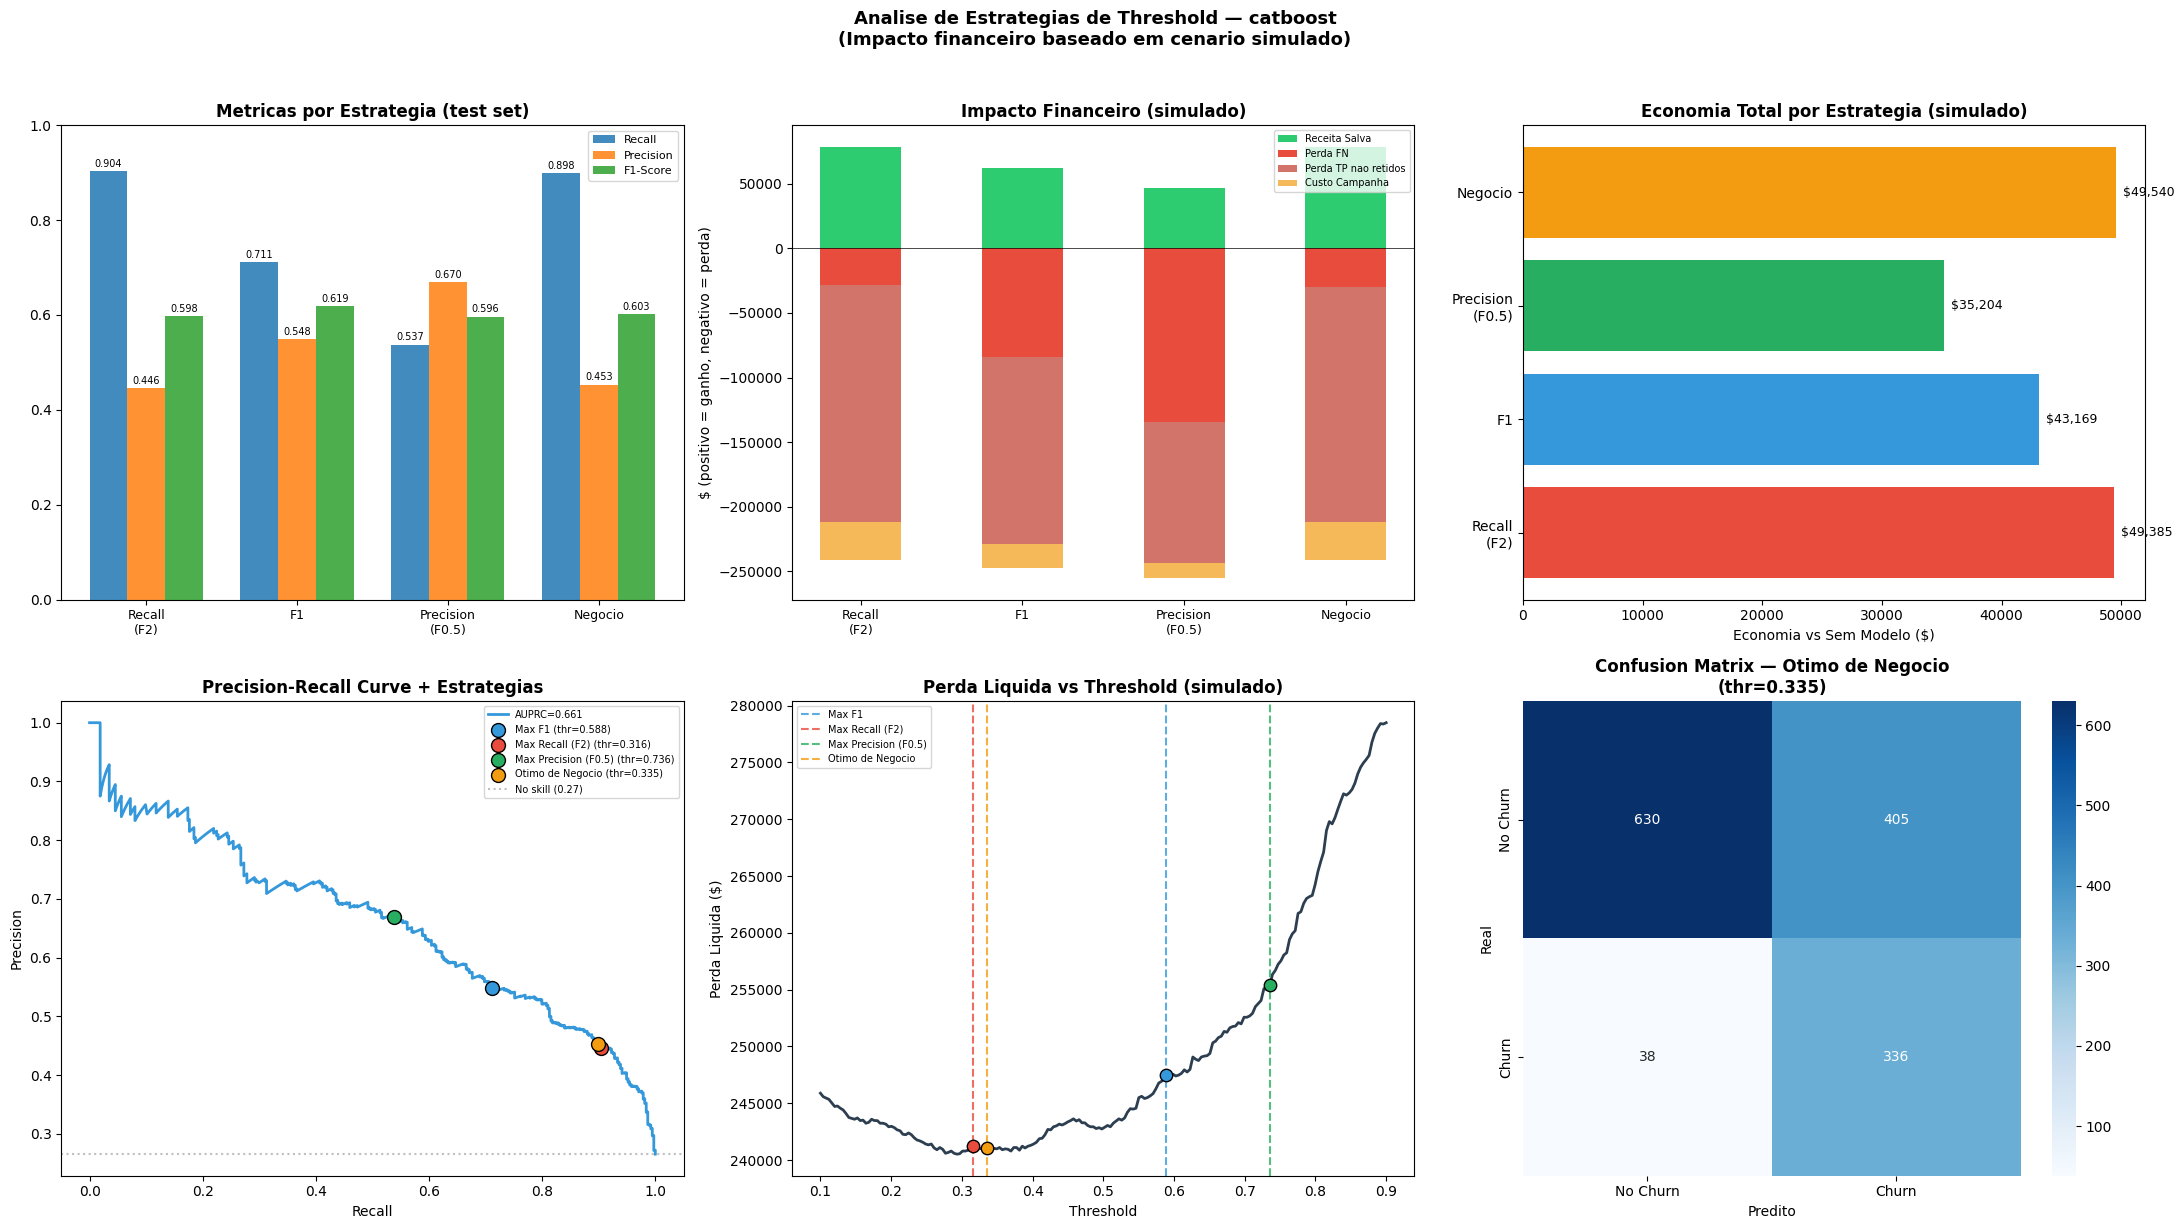


COMPARACAO OTIMO DE NEGOCIO vs BASELINE
--------------------------------------------------
  AUPRC          : 0.6325 -> 0.6612 (+0.0287)
  F1-Score       : 0.6136 -> 0.6027 (-0.0109)
  Recall         : 0.7834 -> 0.8984 (+0.1150)
  Precision      : 0.5043 -> 0.4534 (-0.0509)
  ROC-AUC        : 0.8415 -> 0.8465 (+0.0050)

  Gap AUPRC CV->Test: +0.0062 (0.9%)
  (gap < 5% = boa generalizacao, sem overfitting significativo)


In [10]:
# ============================================================
# TREINAR MODELO FINAL + ANALISE DE THRESHOLD + BUSINESS IMPACT
# ============================================================
# Metodologia:
#   1. Treina o modelo final (melhor trial do Optuna) em todo o train set
#   2. Gera probabilidades OOF via cross_val_predict no train (sem data leakage)
#   3. Otimiza 4 estratégias de threshold usando apenas dados de TREINO (CV)
#   4. Avalia cada estratégia no test set (dados nunca vistos)
#   5. Seleciona a estratégia com menor perda líquida de receita
#
# CENARIO SIMULADO: Os parâmetros de negócio (custo de campanha, taxa de
# retenção) são ESTIMATIVAS baseadas em benchmarks do setor de telecom.
# O dataset IBM Telco Customer Churn não contém dados reais de campanhas
# de retenção. Em produção, esses valores devem ser calibrados com dados
# reais da operação.
# ============================================================

best_trial = study.best_trial
best_algo = best_trial.params['algorithm']

# Extrair parametros do melhor trial (filtrar por algoritmo)
raw_params = best_trial.params.copy()
raw_params.pop('algorithm')
pos_w = raw_params.pop('pos_weight')

filtered = {}
if best_algo == 'xgboost':
    for k, v in raw_params.items():
        if k.startswith('lgbm_') or k.startswith('cat_'):
            continue
        filtered[k.replace('xgb_', '')] = v
    filtered['scale_pos_weight'] = pos_w
    final_model = XGBClassifier(**filtered, random_state=RANDOM_STATE, verbosity=0, n_jobs=-1)

elif best_algo == 'lightgbm':
    for k, v in raw_params.items():
        if k.startswith('xgb_') or k.startswith('cat_'):
            continue
        filtered[k.replace('lgbm_', '')] = v
    filtered['class_weight'] = {0: 1, 1: pos_w}
    final_model = LGBMClassifier(**filtered, random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)

else:  # catboost
    for k, v in raw_params.items():
        if k.startswith('xgb_') or k.startswith('lgbm_'):
            continue
        filtered[k.replace('cat_', '')] = v
    filtered['scale_pos_weight'] = pos_w
    filtered['iterations'] = filtered.pop('n_estimators')
    filtered['depth'] = filtered.pop('max_depth')
    filtered['rsm'] = filtered.pop('colsample_bytree')
    final_model = CatBoostClassifier(**filtered, random_seed=RANDOM_STATE, verbose=0)

# Treinar no train set completo
final_model.fit(X_train_opt, y_train)
print(f"Modelo: {best_algo}")
print(f"AUPRC (CV): {best_trial.value:.4f}")
print(f"Treinado: {X_train_opt.shape[0]} amostras, {X_train_opt.shape[1]} features\n")

# ── THRESHOLD OPTIMIZATION via CV (sem data leakage)
# Todas as estratégias de threshold são otimizadas usando probabilidades
# out-of-fold (OOF) do cross_val_predict no TRAIN set.
# Isso garante que nenhuma informação do test set influencia a escolha.
cv_thr = StratifiedKFold(n_splits=CV_FOLDS_OPT, shuffle=True, random_state=RANDOM_STATE)
y_proba_cv = cross_val_predict(final_model, X_train_opt, y_train, cv=cv_thr, method='predict_proba', n_jobs=1)[:, 1]

prec_cv, rec_cv, thr_cv = precision_recall_curve(y_train, y_proba_cv)

# Funcao F-beta generalizada
# F_beta = (1 + beta^2) * (P * R) / (beta^2 * P + R)
# beta > 1: recall pesa mais | beta < 1: precision pesa mais | beta = 1: equilibrio
def fbeta_array(prec, rec, beta):
    return (1 + beta**2) * (prec * rec) / (beta**2 * prec + rec + 1e-10)

# ── 3 ESTRATEGIAS DE THRESHOLD ESTATISTICAS (otimizadas no CV)
strategies = {}

# 1. Maximizar F1 (beta=1.0)
# Equilibra Precision e Recall igualmente — ponto de referência padrão
f1_cv = fbeta_array(prec_cv, rec_cv, beta=1.0)
idx_f1 = np.argmax(f1_cv[:-1])
strategies['Max F1'] = {
    'threshold': float(thr_cv[idx_f1]),
    'description': 'Equilibrio Precision-Recall (F1 = media harmonica)',
    'color': '#3498db',
    'beta': 1.0
}

# 2. Priorizar Recall (beta=2.0)
# Recall pesa 4x mais que Precision na formula do F-beta
# Indicado quando o custo de perder um churner (FN) e muito maior que
# o custo de uma ação de retenção desnecessária (FP)
f2_cv = fbeta_array(prec_cv, rec_cv, beta=2.0)
idx_f2 = np.argmax(f2_cv[:-1])
strategies['Max Recall (F2)'] = {
    'threshold': float(thr_cv[idx_f2]),
    'description': 'Prioriza capturar churners (recall 4x mais importante que precision)',
    'color': '#e74c3c',
    'beta': 2.0
}

# 3. Priorizar Precision (beta=0.5)
# Precision pesa 4x mais que Recall na formula do F-beta
# Indicado quando campanhas de retenção são caras e devem ser
# direcionadas apenas a clientes com alta probabilidade de churn
f05_cv = fbeta_array(prec_cv, rec_cv, beta=0.5)
idx_f05 = np.argmax(f05_cv[:-1])
strategies['Max Precision (F0.5)'] = {
    'threshold': float(thr_cv[idx_f05]),
    'description': 'Prioriza certeza nas predicoes (precision 4x mais importante que recall)',
    'color': '#27ae60',
    'beta': 0.5
}

# ── PARAMETROS DE NEGOCIO (CENARIO SIMULADO)
# ⚠️ ESTES VALORES SÃO ESTIMATIVAS — não existem no dataset original.
# Em produção, devem ser substituídos por dados reais da operação.
#
# Premissas:
# - Receita anual/cliente: MonthlyCharges × 12 (dado real do dataset)
# - Custo campanha: ~20% desconto por 3 meses (estimativa de mercado)
#   Referência: programas de retenção em telecom oferecem 10-30% de desconto
#   por 3-6 meses (fonte: benchmarks do setor)
# - Taxa de sucesso: 30% (estimativa conservadora)
#   Referência: campanhas proativas de retenção em telecom têm taxas
#   de sucesso entre 20-40% (fonte: análises setoriais)
monthly_charges = pd.to_numeric(df['MonthlyCharges'], errors='coerce')
media_mensal = monthly_charges.mean()
VALOR_MEDIO_CLIENTE = round(media_mensal * 12, 2)  # Receita anual (CALCULADO dos dados reais)
TAXA_SUCESSO_RETENCAO = 0.30  # SIMULADO — taxa estimada de retenção após campanha
CUSTO_CAMPANHA_POR_CLIENTE = round(media_mensal * 0.20 * 3, 2)  # SIMULADO — 20% desconto × 3 meses

print(f"PARAMETROS DE NEGOCIO (CENARIO SIMULADO)")
print(f"  Receita media anual/cliente:  ${VALOR_MEDIO_CLIENTE:,.2f}  (calculado dos dados)")
print(f"  Custo campanha/cliente:       ${CUSTO_CAMPANHA_POR_CLIENTE:,.2f}  (SIMULADO: 20% desconto × 3 meses)")
print(f"  Taxa sucesso retencao:        {TAXA_SUCESSO_RETENCAO:.0%}  (SIMULADO: estimativa conservadora)")

# ── 4. THRESHOLD OTIMO DE NEGOCIO (otimizado no CV — sem data leakage)
# Varre TODOS os thresholds da curva Precision-Recall obtida via
# cross_val_predict no train, e encontra o threshold que minimiza
# a perda líquida total:
#   Perda = Perda_FN + Perda_TP_nao_retidos + Custo_Campanha
# onde Perda_TP_nao_retidos = TP × (1 - taxa_retencao) × CLV
# (churners detectados mas que cancelam mesmo após campanha)
total_churners_cv = y_train.sum()
best_biz_loss = float('inf')
best_biz_thr = 0.5

for i in range(len(thr_cv)):
    # Estimar TP, FP, FN a partir de Precision e Recall no CV
    tp_i = rec_cv[i] * total_churners_cv
    fp_i = (tp_i / (prec_cv[i] + 1e-10)) - tp_i if prec_cv[i] > 0 else 0
    fn_i = total_churners_cv - tp_i
    custo_i = (tp_i + fp_i) * CUSTO_CAMPANHA_POR_CLIENTE
    perda_nao_retidos_i = tp_i * (1 - TAXA_SUCESSO_RETENCAO) * VALOR_MEDIO_CLIENTE
    perda_i = fn_i * VALOR_MEDIO_CLIENTE + perda_nao_retidos_i + custo_i
    if perda_i < best_biz_loss:
        best_biz_loss = perda_i
        best_biz_thr = float(thr_cv[i])

strategies['Otimo de Negocio'] = {
    'threshold': best_biz_thr,
    'description': 'Minimiza perda liquida total via sweep no CV (sem data leakage)',
    'color': '#f39c12',
    'beta': None
}

# ── AVALIAR TODAS AS ESTRATEGIAS NO TEST SET
y_proba_final = final_model.predict_proba(X_test_opt)[:, 1]
auprc_test = average_precision_score(y_test, y_proba_final)

# Baseline AUPRC
auprc_baseline = average_precision_score(y_test, y_proba_base)
baseline_metrics['AUPRC'] = auprc_baseline

results = {}
for name, strat in strategies.items():
    thr = strat['threshold']
    y_pred = (y_proba_final >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Metricas de classificacao
    metrics = {
        'Threshold': thr,
        'AUPRC': auprc_test,
        'F1-Score': f1_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba_final),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    }

    # Impacto financeiro (CENARIO SIMULADO)
    # Perda Liquida = Perda_FN + Perda_TP_nao_retidos + Custo_Campanha
    total_churners = tp + fn
    receita_salva = tp * TAXA_SUCESSO_RETENCAO * VALOR_MEDIO_CLIENTE
    perda_fn = fn * VALOR_MEDIO_CLIENTE
    perda_tp_nao_retidos = tp * (1 - TAXA_SUCESSO_RETENCAO) * VALOR_MEDIO_CLIENTE
    custo_campanha = (tp + fp) * CUSTO_CAMPANHA_POR_CLIENTE
    perda_total_sem_modelo = total_churners * VALOR_MEDIO_CLIENTE

    metrics['Receita Salva'] = receita_salva
    metrics['Perda FN'] = perda_fn
    metrics['Perda TP nao retidos'] = perda_tp_nao_retidos
    metrics['Custo Campanha'] = custo_campanha
    metrics['Perda Liquida'] = perda_fn + perda_tp_nao_retidos + custo_campanha
    metrics['Perda sem Modelo'] = perda_total_sem_modelo
    metrics['Economia'] = perda_total_sem_modelo - metrics['Perda Liquida']
    metrics['ROI Campanha'] = (receita_salva - custo_campanha) / custo_campanha if custo_campanha > 0 else 0

    results[name] = metrics

# ============================================================
# TABELA COMPARATIVA
# ============================================================
print(f"\n{'='*90}")
print(f"ANALISE COMPARATIVA DE ESTRATEGIAS DE THRESHOLD")
print(f"{'='*90}")
print(f"(Thresholds otimizados no CV | Metricas avaliadas no test set)")
print(f"(Impacto financeiro baseado em CENARIO SIMULADO)\n")

header = f"{'Estrategia':22s} {'Thr':>5s} {'Recall':>7s} {'Prec':>7s} {'F1':>7s} {'TP':>4s} {'FP':>4s} {'FN':>4s} {'Perda Liq':>12s} {'Economia':>12s}"
print(header)
print("-"*90)
for name in ['Max Recall (F2)', 'Max F1', 'Max Precision (F0.5)', 'Otimo de Negocio']:
    r = results[name]
    print(f"  {name:20s} {r['Threshold']:5.3f} {r['Recall']:7.4f} {r['Precision']:7.4f} "
          f"{r['F1-Score']:7.4f} {r['TP']:4d} {r['FP']:4d} {r['FN']:4d} "
          f"${r['Perda Liquida']:>10,.0f} ${r['Economia']:>10,.0f}")

# Melhor estrategia por economia
melhor = max(results.items(), key=lambda x: x[1]['Economia'])
print(f"\n>>> MELHOR ESTRATEGIA (MENOR PERDA DE RECEITA): {melhor[0]}")
print(f"    Threshold: {melhor[1]['Threshold']:.4f}")
print(f"    Economia vs sem modelo: ${melhor[1]['Economia']:,.0f}")
print(f"    ROI Campanha: {melhor[1]['ROI Campanha']:.1%}")

print(f"\nDETALHAMENTO FINANCEIRO POR ESTRATEGIA (CENARIO SIMULADO):")
print(f"-"*90)
for name in ['Max Recall (F2)', 'Max F1', 'Max Precision (F0.5)', 'Otimo de Negocio']:
    r = results[name]
    print(f"\n  {name} (threshold={r['Threshold']:.3f}):")
    print(f"    Receita salva (TP×30%×CLV):        ${r['Receita Salva']:>10,.0f}  ({r['TP']} detectados × 30% retencao)")
    print(f"    Perda por FN (churners perdidos):   ${r['Perda FN']:>10,.0f}  ({r['FN']} nao detectados)")
    print(f"    Perda TP nao retidos (TP×70%×CLV):  ${r['Perda TP nao retidos']:>10,.0f}  ({r['TP']} detectados × 70% nao retidos)")
    print(f"    Custo campanha (TP+FP):             ${r['Custo Campanha']:>10,.0f}  ({r['TP']+r['FP']} contactados)")
    print(f"    PERDA LIQUIDA:                      ${r['Perda Liquida']:>10,.0f}")

# ============================================================
# VISUALIZACAO
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
fig.suptitle(f'Analise de Estrategias de Threshold — {best_algo}\n'
             f'(Impacto financeiro baseado em cenario simulado)',
             fontsize=13, fontweight='bold', y=1.02)

# Curva PR no test set (para visualizacao — thresholds vêm do CV)
prec_t, rec_t, thr_t = precision_recall_curve(y_test, y_proba_final)

# 1. Comparacao de metricas por estrategia
ax = axes[0, 0]
strat_names_short = ['Recall\n(F2)', 'F1', 'Precision\n(F0.5)', 'Negocio']
strat_keys = ['Max Recall (F2)', 'Max F1', 'Max Precision (F0.5)', 'Otimo de Negocio']
colors = [strategies[k]['color'] for k in strat_keys]
x_pos = np.arange(len(strat_keys))
metric_vals = {m: [results[k][m] for k in strat_keys] for m in ['Recall', 'Precision', 'F1-Score']}
width = 0.25
for i, (m, vals) in enumerate(metric_vals.items()):
    bars = ax.bar(x_pos + i*width - width, vals, width, label=m, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.annotate(f'{v:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=7)
ax.set_xticks(x_pos)
ax.set_xticklabels(strat_names_short, fontsize=9)
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.set_title('Metricas por Estrategia (test set)', fontweight='bold')

# 2. Impacto financeiro (barras empilhadas)
ax = axes[0, 1]
receita_vals = [results[k]['Receita Salva'] for k in strat_keys]
perda_fn_vals = [results[k]['Perda FN'] for k in strat_keys]
perda_tp_nr_vals = [results[k]['Perda TP nao retidos'] for k in strat_keys]
custo_camp_vals = [results[k]['Custo Campanha'] for k in strat_keys]
x_pos = np.arange(len(strat_keys))
ax.bar(x_pos, receita_vals, 0.5, label='Receita Salva', color='#2ecc71')
ax.bar(x_pos, [-v for v in perda_fn_vals], 0.5, label='Perda FN', color='#e74c3c')
perda_fn_bottom = [-v for v in perda_fn_vals]
ax.bar(x_pos, [-v for v in perda_tp_nr_vals], 0.5, bottom=perda_fn_bottom,
       label='Perda TP nao retidos', color='#c0392b', alpha=0.7)
combined_bottom = [a + b for a, b in zip(perda_fn_bottom, [-v for v in perda_tp_nr_vals])]
ax.bar(x_pos, [-v for v in custo_camp_vals], 0.5, bottom=combined_bottom,
       label='Custo Campanha', color='#f39c12', alpha=0.7)
ax.set_xticks(x_pos)
ax.set_xticklabels(strat_names_short, fontsize=9)
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(fontsize=7)
ax.set_ylabel('$ (positivo = ganho, negativo = perda)')
ax.set_title('Impacto Financeiro (simulado)', fontweight='bold')

# 3. Economia total (horizontal bar)
ax = axes[0, 2]
economia_vals = [results[k]['Economia'] for k in strat_keys]
bars = ax.barh(strat_names_short, economia_vals, color=colors)
for bar, val in zip(bars, economia_vals):
    ax.annotate(f'${val:,.0f}', xy=(val, bar.get_y() + bar.get_height()/2),
                xytext=(5, 0), textcoords="offset points", ha='left', va='center', fontsize=9)
ax.set_xlabel('Economia vs Sem Modelo ($)')
ax.set_title('Economia Total por Estrategia (simulado)', fontweight='bold')

# 4. Precision-Recall Curve com thresholds
ax = axes[1, 0]
ax.plot(rec_t, prec_t[:-1] if len(prec_t) > len(rec_t) else prec_t,
        color='#3498db', linewidth=2, label=f'AUPRC={auprc_test:.3f}')
for name, strat in strategies.items():
    r = results[name]
    ax.scatter(r['Recall'], r['Precision'], color=strat['color'], s=100, zorder=5,
               label=f"{name} (thr={strat['threshold']:.3f})", edgecolors='black')
ax.axhline(y_test.mean(), color='gray', linestyle=':', alpha=0.5, label=f'No skill ({y_test.mean():.2f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve + Estrategias', fontweight='bold')
ax.legend(fontsize=7, loc='upper right')

# 5. Perda liquida x Threshold (sweep no test set — apenas visualizacao)
ax = axes[1, 1]
losses = []
thresholds_sweep = np.linspace(0.1, 0.9, 200)
for thr_i in thresholds_sweep:
    yp = (y_proba_final >= thr_i).astype(int)
    cm_i = confusion_matrix(y_test, yp)
    tn_i, fp_i, fn_i, tp_i = cm_i.ravel()
    loss_i = (fn_i * VALOR_MEDIO_CLIENTE
              + tp_i * (1 - TAXA_SUCESSO_RETENCAO) * VALOR_MEDIO_CLIENTE
              + (tp_i + fp_i) * CUSTO_CAMPANHA_POR_CLIENTE)
    losses.append(loss_i)
ax.plot(thresholds_sweep, losses, color='#2c3e50', linewidth=2)
for name, strat in strategies.items():
    r = results[name]
    ax.axvline(strat['threshold'], color=strat['color'], linestyle='--', alpha=0.8, label=name)
    ax.scatter(strat['threshold'], r['Perda Liquida'], color=strat['color'], s=80, zorder=5, edgecolors='black')
ax.set_xlabel('Threshold')
ax.set_ylabel('Perda Liquida ($)')
ax.set_title('Perda Liquida vs Threshold (simulado)', fontweight='bold')
ax.legend(fontsize=7)

# 6. Confusion matrix (melhor estrategia)
ax = axes[1, 2]
cm_best = confusion_matrix(y_test, (y_proba_final >= melhor[1]['Threshold']).astype(int))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title(f'Confusion Matrix — {melhor[0]}\n(thr={melhor[1]["Threshold"]:.3f})', fontweight='bold')

plt.tight_layout()
plt.show()

# ── COMPARACAO COM BASELINE
print(f"\nCOMPARACAO {melhor[0].upper()} vs BASELINE")
print("-"*50)
for m in ['AUPRC', 'F1-Score', 'Recall', 'Precision', 'ROC-AUC']:
    delta = melhor[1][m] - baseline_metrics[m]
    print(f"  {m:15s}: {baseline_metrics[m]:.4f} -> {melhor[1][m]:.4f} ({delta:+.4f})")

gap_auprc = best_trial.value - auprc_test
print(f"\n  Gap AUPRC CV->Test: {gap_auprc:+.4f} ({abs(gap_auprc)/best_trial.value*100:.1f}%)")
print(f"  (gap < 5% = boa generalizacao, sem overfitting significativo)")

# Aliases para celulas seguintes
best_model_name = best_algo
best_threshold = melhor[1]['Threshold']
optimized_metrics = {k: melhor[1][k] for k in ['AUPRC', 'F1-Score', 'Recall', 'Precision', 'ROC-AUC']}
y_pred_optimized = (y_proba_final >= best_threshold).astype(int)
best_strategy_name = melhor[0]

## 6. Avaliação Detalhada — Análise de Estratégias de Threshold

### Por que otimizar o threshold?

O threshold padrão de 0.5 assume que os erros de classificação (falso positivo e falso negativo) têm o **mesmo custo**. Em problemas de churn, isso raramente é verdade:

- **Falso Negativo (FN):** Um churner que o modelo não detectou → a empresa perdeu toda a receita anual desse cliente.
- **Falso Positivo (FP):** Um cliente estável que recebeu uma campanha de retenção desnecessária → custo de desconto/oferta, mas o cliente permaneceu.

O custo assimétrico dessas decisões justificou a exploração de thresholds diferentes de 0.5.

### Metodologia: Otimização no CV (sem data leakage)

Todos os thresholds foram otimizados usando **probabilidades out-of-fold** (OOF) geradas por `cross_val_predict` no **train set**. Isso garantiu que:

1. Nenhuma informação do test set influenciou a escolha do threshold.
2. As probabilidades OOF foram geradas em dados "não vistos" pelo modelo naquele fold (análogo a um mini-test set).
3. O threshold escolhido generalizou melhor para produção.

### As 4 Estratégias

| Estratégia | Métrica Otimizada | Fórmula | Quando usar |
|------------|-------------------|---------|-------------|
| **Max Recall (F2)** | $F_2$ | $\frac{5 \cdot P \cdot R}{4P + R}$ | Quando perder um churner (FN) era muito mais caro que uma campanha desnecessária (FP) |
| **Max F1** | $F_1$ | $\frac{2 \cdot P \cdot R}{P + R}$ | Quando os custos de FP e FN eram comparáveis |
| **Max Precision (F0.5)** | $F_{0.5}$ | $\frac{1.25 \cdot P \cdot R}{0.25P + R}$ | Quando campanhas eram caras e deviam ser direcionadas com alta confiança |
| **Ótimo de Negócio** | Perda líquida | $L = \text{Perda}_{FN} + \text{Perda}_{TP\_nr} + \text{Custo}_{campanha}$ | Quando se conheciam os custos reais de FP, FN e campanha |

A métrica $F_\beta$ generaliza o F1-Score com um parâmetro $\beta$ que controla o peso relativo:

$$F_\beta = \frac{(1 + \beta^2) \cdot P \cdot R}{\beta^2 \cdot P + R}$$

- $\beta > 1$: Recall pesa mais (F2 → recall tem peso 4× sobre precision)
- $\beta = 1$: Equilíbrio (F1 padrão)
- $\beta < 1$: Precision pesa mais (F0.5 → precision tem peso 4× sobre recall)

### Impacto Financeiro por Estratégia

> **⚠️ Cenário simulado:** Os cálculos financeiros abaixo usaram premissas estimadas, não dados reais da operação. O dataset IBM Telco Customer Churn **não contém** informações sobre campanhas de retenção, custos operacionais ou taxas de sucesso.

Cada estratégia gerou um trade-off direto e mensurável na receita:

| Componente | Fórmula | Origem do dado |
|------------|---------|----------------|
| **Receita salva** | $TP \times 30\% \times CLV_{anual}$ | CLV = dado real; taxa 30% = **simulada** |
| **Perda por FN** | $FN \times CLV_{anual}$ | CLV = dado real |
| **Perda TP não retidos** | $TP \times 70\% \times CLV_{anual}$ | Churners detectados mas não retidos pela campanha |
| **Custo campanha** | $(TP + FP) \times \text{custo}_{campanha}$ | Custo = **simulado** (20% desconto × 3 meses) |
| **Perda líquida** | $\text{Perda}_{FN} + \text{Perda}_{TP\_nr} + \text{Custo}_{campanha}$ | Composição de reais + simulados |

**Nota:** A Economia = Perda_sem_modelo − Perda_líquida. Como Perda_sem_modelo = $(TP+FN) \times CLV$ e Perda_líquida inclui todos os custos, a Economia equivaleu a $\text{Receita}_{salva} - \text{Custo}_{campanha}$.

**Premissas simuladas e suas referências:**
- **Taxa de sucesso de retenção (30%):** Campanhas proativas de retenção em telecom têm taxas entre 20-40% (Literatura: Hadden et al., 2007; Verbeke et al., 2012). O valor de 30% foi conservador.
- **Custo de campanha (~20% desconto × 3 meses):** Programas típicos de retenção em telecom oferecem descontos entre 10-30% por períodos de 3-6 meses. O valor de 20% foi intermediário.
- **CLV anualizado (MonthlyCharges × 12):** Calculado diretamente dos dados reais do dataset. Foi uma simplificação que desconsiderou variação de receita ao longo do tempo.

### Decisão

A estratégia final foi selecionada pela **maior economia líquida** (menor perda total de receita). Essa abordagem traduziu o trade-off Precision×Recall em termos financeiros, facilitando a comunicação com stakeholders de negócio.

In [11]:
# ============================================================
# SALVAR MODELO FINAL
# ============================================================

MODELS_DIR = PROJ_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

model_path = MODELS_DIR / f"churn_model_{best_model_name}.joblib"
joblib.dump({
    'model': final_model,
    'preprocessor': preprocessor_fitted,
    'feature_engineer': advanced_fe,
    'model_name': best_model_name,
    'params': filtered,
    'metrics': optimized_metrics,
    'threshold': best_threshold,
    'threshold_strategy': best_strategy_name,
    'label_encoder': label_encoder,
    'timestamp': datetime.now().isoformat()
}, model_path)

print(f"Modelo salvo: {model_path}")
print(f"  Tipo: {best_model_name}")
print(f"  Estrategia: {best_strategy_name}")
print(f"  Threshold: {best_threshold:.4f}")
print(f"  AUPRC: {optimized_metrics['AUPRC']:.4f}")
print(f"  F1: {optimized_metrics['F1-Score']:.4f}")
print(f"  Recall: {optimized_metrics['Recall']:.4f}")
print(f"  Precision: {optimized_metrics['Precision']:.4f}")

Modelo salvo: /home/gabriela/Projetos/telco_churn_clients/models/churn_model_catboost.joblib
  Tipo: catboost
  Estrategia: Otimo de Negocio
  Threshold: 0.3354
  AUPRC: 0.6612
  F1: 0.6027
  Recall: 0.8984
  Precision: 0.4534


## 7. Business Impact — Impacto Financeiro do Modelo

> **⚠️ Cenário simulado:** Os cálculos financeiros desta seção utilizaram **premissas estimadas** baseadas em benchmarks do setor de telecomunicações. O dataset original (IBM Telco Customer Churn) contém apenas dados de perfil e uso de clientes — **não inclui dados reais sobre campanhas de retenção, custos operacionais ou taxas de sucesso.**

### O que era real vs. simulado

| Dado | Fonte | Tipo |
|------|-------|------|
| `MonthlyCharges` | Dataset IBM Telco | **Real** — receita mensal por cliente |
| CLV anualizado (`MonthlyCharges × 12`) | Calculado dos dados | **Derivado** — simplificação que assumiu 12 meses de permanência |
| TP, FP, FN, TN | Modelo de ML | **Real** — resultados da classificação no test set |
| Taxa de sucesso de retenção (30%) | Estimativa | **Simulado** — benchmarks sugeriam 20-40% para telecom |
| Custo campanha por cliente | Estimativa | **Simulado** — 20% de desconto por 3 meses |
| Perda líquida / economia | Fórmula | **Derivado** — combinou dados reais e simulados |

### Premissas de negócio

| Parâmetro | Valor | Descrição | Sensibilidade |
|-----------|-------|-----------|---------------|
| Receita anual/cliente | Calculado | `MonthlyCharges × 12` | Baixa — dado real |
| Custo campanha/cliente | Calculado | `MonthlyCharges × 20% × 3 meses` | **Alta** — desconto e duração afetaram diretamente o ROI |
| Taxa de sucesso | 30% | % de clientes retidos após campanha | **Alta** — se taxa real fosse 15%, economia cairia pela metade |

### Cenários comparados

- **Sem modelo:** Nenhuma ação proativa — todos os churners teriam sido perdidos.
- **Com modelo:** Threshold selecionado identificou churners → campanha de retenção teria sido direcionada.

### Para uso em produção

Os valores simulados deveriam ser substituídos por dados reais antes de qualquer decisão de investimento:
1. Medir a **taxa real de retenção** com testes A/B em campanhas piloto
2. Calcular o **custo real de campanha** incluindo desconto, operação e atendimento
3. Refinar o **CLV** com dados de receita histórica por cliente (não apenas MonthlyCharges)

In [12]:
# ============================================================
# BUSINESS IMPACT — RESUMO EXECUTIVO (CENARIO SIMULADO)
# ============================================================
# ⚠️ Os valores financeiros abaixo combinam:
#   - Dados REAIS: TP, FP, FN, TN (saída do modelo) e MonthlyCharges
#   - Dados SIMULADOS: taxa de retenção (30%) e custo de campanha (20% desc × 3 meses)
# Em produção, substituir por dados reais da operação.
# ============================================================

cm_opt = confusion_matrix(y_test, y_pred_optimized)
tn, fp, fn, tp = cm_opt.ravel()
total_churners = tp + fn

# Cenario SEM modelo
perda_sem_modelo = total_churners * VALOR_MEDIO_CLIENTE

# Cenario COM modelo (estrategia escolhida)
clientes_contactados = tp + fp
clientes_salvos = tp * TAXA_SUCESSO_RETENCAO
receita_preservada = clientes_salvos * VALOR_MEDIO_CLIENTE
custo_campanha_total = clientes_contactados * CUSTO_CAMPANHA_POR_CLIENTE
perda_fn = fn * VALOR_MEDIO_CLIENTE
perda_tp_nao_retidos = tp * (1 - TAXA_SUCESSO_RETENCAO) * VALOR_MEDIO_CLIENTE
perda_com_modelo = perda_fn + perda_tp_nao_retidos + custo_campanha_total

economia_liquida = perda_sem_modelo - perda_com_modelo

print(f"RESUMO EXECUTIVO — Estrategia: {best_strategy_name}")
print(f"{'='*60}")
print(f"  Threshold:                {best_threshold:.4f}")
print(f"  Receita media anual:      ${VALOR_MEDIO_CLIENTE:,.2f}/cliente  (CALCULADO dos dados)")
print(f"  Custo campanha:           ${CUSTO_CAMPANHA_POR_CLIENTE:,.2f}/cliente  (SIMULADO)")
print(f"  Taxa sucesso retencao:    {TAXA_SUCESSO_RETENCAO:.0%}  (SIMULADO)")

print(f"\nCenario SEM modelo:")
print(f"  Churners perdidos:        {total_churners}")
print(f"  Perda total:              ${perda_sem_modelo:,.0f}")

print(f"\nCenario COM modelo ({best_strategy_name}):")
print(f"  Churners detectados (TP): {tp}")
print(f"  Falsos alertas (FP):      {fp}")
print(f"  Churners perdidos (FN):   {fn}")
print(f"  Clientes contactados:     {clientes_contactados}")
print(f"  Clientes salvos (est.):   {clientes_salvos:.0f}")
print(f"  Receita preservada:       ${receita_preservada:,.0f}")
print(f"  Custo campanha:           ${custo_campanha_total:,.0f}")
print(f"  Perda por FN:             ${perda_fn:,.0f}")
print(f"  Perda TP nao retidos:     ${perda_tp_nao_retidos:,.0f}")

print(f"\nRESULTADO (CENARIO SIMULADO):")
print(f"  Perda com modelo:         ${perda_com_modelo:,.0f}")
print(f"  Economia liquida:         ${economia_liquida:,.0f}")
print(f"  Retorno / perda total:    {(receita_preservada / perda_sem_modelo)*100:.1f}% recuperado")
print(f"  ROI campanha:             {((receita_preservada - custo_campanha_total) / custo_campanha_total)*100:.0f}%")
print(f"\n⚠️  Valores financeiros baseados em cenario simulado.")
print(f"    Em producao, calibrar com dados reais de campanhas.")

RESUMO EXECUTIVO — Estrategia: Otimo de Negocio
  Threshold:                0.3354
  Receita media anual:      $777.14/cliente  (CALCULADO dos dados)
  Custo campanha:           $38.86/cliente  (SIMULADO)
  Taxa sucesso retencao:    30%  (SIMULADO)

Cenario SEM modelo:
  Churners perdidos:        374
  Perda total:              $290,650

Cenario COM modelo (Otimo de Negocio):
  Churners detectados (TP): 336
  Falsos alertas (FP):      405
  Churners perdidos (FN):   38
  Clientes contactados:     741
  Clientes salvos (est.):   101
  Receita preservada:       $78,336
  Custo campanha:           $28,795
  Perda por FN:             $29,531
  Perda TP nao retidos:     $182,783

RESULTADO (CENARIO SIMULADO):
  Perda com modelo:         $241,110
  Economia liquida:         $49,540
  Retorno / perda total:    27.0% recuperado
  ROI campanha:             172%

⚠️  Valores financeiros baseados em cenario simulado.
    Em producao, calibrar com dados reais de campanhas.


## Conclusões

### Resumo da Pipeline

Este notebook implementou uma pipeline completa e documentada de otimização para predição de churn:

| Etapa | Técnica | Justificativa |
|-------|---------|---------------|
| Feature Engineering | `AdvancedFeatureEngineer` (19→~59 features) + remoção IV=0 | Criou interações e indicadores de risco; removeu features sem poder preditivo |
| Preprocessing | `StandardScaler` + `OneHotEncoder` via `ColumnTransformer` | Normalizou numéricas, codificou categóricas como dummies |
| Otimização | Optuna (TPE Bayesiano) — AUPRC como objetivo | Threshold-independente, estável, focado na classe positiva |
| Modelos | XGBoost, LightGBM, CatBoost (seleção automática) | Os 3 frameworks de gradient boosting mais eficientes competiram entre si |
| Balanceamento | `scale_pos_weight` / `class_weight` (1.5x–12x) | Otimizado como hiperparâmetro, mais estável que SMOTE |
| Threshold | 4 estratégias (F2, F1, F0.5, Ótimo de Negócio) | Escolha baseada em menor perda líquida de receita |

### Principais Aprendizados Técnicos

- **AUPRC como objetivo de otimização** mostrou-se mais estável e adequado para dados desbalanceados do que F1 com threshold fixo — evitou a variância de escolher um threshold diferente em cada trial.
- **Threshold não foi uma decisão estatística, foi de negócio** — a escolha entre Precision e Recall dependeu dos custos relativos de FN (perder cliente) vs FP (campanha desnecessária). O $F_\beta$ parametrizou essa decisão.
- **class_weight como hiperparâmetro** otimizado por Optuna mostrou-se mais estável e simples que SMOTE/reamostragem, sem necessidade de reamostragem dentro de cada fold de CV.
- **Análise financeira traduziu métricas em valor de negócio** — facilitou comunicação com stakeholders e justificou investimento em ML.

### Cenário Simulado — Limitações

> **⚠️ Importante:** A análise de impacto financeiro (Business Impact) utilizou **premissas simuladas** para taxa de retenção (30%) e custo de campanha (20% desconto × 3 meses). O dataset IBM Telco Customer Churn **não contém dados reais sobre campanhas de retenção**.
>
> As conclusões financeiras foram **demonstrativas** — ilustraram a metodologia de avaliação, mas os valores absolutos (economia, ROI) não deveriam ser usados para decisões de investimento sem calibração com dados reais da operação.

### Artefatos Gerados

| Artefato | Caminho | Descrição |
|----------|---------|-----------|
| Modelo Final | `models/churn_model_*.joblib` | Modelo + preprocessor + feature engineer + threshold + metadata |
| Estudo Optuna | `optuna_studies/study_unified_auprc_v1.pkl` | Histórico completo de trials (hiperparâmetros + métricas) |
| Experimentos MLflow | `mlruns/` | Tracking de métricas e parâmetros para reprodutibilidade |

### Próximos Passos

1. **SHAP Analysis** — Interpretar predições e identificar features mais influentes para decisões de retenção
2. **Análise de sensibilidade** — Testar como a economia variaria com diferentes taxas de retenção e custos de campanha
3. **Monitoramento** — Detecção de drift para recalibrar threshold e modelo em produção
4. **Deploy** — Servir modelo via API (FastAPI) com threshold configurável